<a href="https://colab.research.google.com/github/littlestuart07/Online-Retail-Analytics-Project/blob/main/Digital%20Assignment%202/DA2_ML_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install xgboost lightgbm --quiet

In [6]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("da2_retail.sqlite")

tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
print("Tables in database:", tables['name'].tolist())

df = pd.read_sql("SELECT * FROM customer_features", conn)
print(f"Retrieved {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Tables in database: ['customer_features', 'transactions_clean']
Retrieved 5281 rows, 13 columns


,Customer ID,Recency,Frequency,Monetary,AvgOrderValue,AvgQuantity,TotalQuantity,OutlierOrders,Country,Churn,HighValue,Segment,CountryGroup
0,12346,235.117361,12,77556.46,6463.038333,2184.852941,74285.0,1,United Kingdom,1.0,1.0,2,United Kingdom
1,12347,39.168056,6,3402.39,567.065000,12.798780,2099.0,6,Iceland,0.0,1.0,3,Other
2,12348,158.085417,4,1709.40,427.350000,52.020833,2497.0,19,Finland,0.0,0.0,3,Other
3,12349,317.185417,3,2671.14,890.380000,9.735294,993.0,1,Italy,0.0,1.0,1,Other
4,12350,219.867361,1,334.40,334.400000,11.588235,197.0,0,Norway,1.0,0.0,3,Other


In [7]:
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                               GradientBoostingClassifier, AdaBoostClassifier)
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve)

feature_cols = ["Recency", "Frequency", "Monetary", "AvgOrderValue",
                 "AvgQuantity", "TotalQuantity", "OutlierOrders", "CountryGroup"]
df_model = pd.get_dummies(df[feature_cols + ["Churn"]], columns=["CountryGroup"], drop_first=True)

X = df_model.drop(columns=["Churn"])
y = df_model["Churn"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"Features used: {list(X.columns)}")

Train: 3960 | Test: 1321
Features used: ['Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'AvgQuantity', 'TotalQuantity', 'OutlierOrders', 'CountryGroup_France', 'CountryGroup_Germany', 'CountryGroup_Other', 'CountryGroup_Spain', 'CountryGroup_United Kingdom']


In [8]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=7),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=8),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1),
    "Support Vector Machine": SVC(probability=True, random_state=42),
    "Linear Discriminant Analysis": LinearDiscriminantAnalysis(),
    "Neural Network (MLP)": MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=500, random_state=42),
}

results = []
for name, model in models.items():
    model.fit(X_train_s, y_train)
    pred = model.predict(X_test_s)
    proba = model.predict_proba(X_test_s)[:, 1]
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1_Score": f1_score(y_test, pred),
        "ROC_AUC": roc_auc_score(y_test, proba)
    })
    print(f"{name:32s} done")

Logistic Regression              done
K-Nearest Neighbors              done
Naive Bayes                      done
Decision Tree                    done
Random Forest                    done
Extra Trees                      done
Gradient Boosting                done
AdaBoost                         done
XGBoost                          done
LightGBM                         done
Support Vector Machine           done
Linear Discriminant Analysis     done
Neural Network (MLP)             done


In [10]:
results_df = pd.DataFrame(results).sort_values("ROC_AUC", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Neural Network (MLP),0.744133,0.759494,0.802139,0.780234,0.806976
1,Gradient Boosting,0.728236,0.736906,0.808824,0.771192,0.805370
2,Logistic Regression,0.736563,0.759740,0.782086,0.770751,0.797293
3,AdaBoost,0.724451,0.740602,0.790107,0.764554,0.793615
4,Linear Discriminant Analysis,0.720666,0.763561,0.733957,0.748466,0.789470
5,Support Vector Machine,0.733535,0.726027,0.850267,0.783251,0.787442
6,Extra Trees,0.724451,0.743038,0.784759,0.763329,0.787292
7,Random Forest,0.722180,0.737828,0.790107,0.763073,0.787175
8,LightGBM,0.718395,0.732673,0.791444,0.760925,0.786715
9,XGBoost,0.705526,0.724656,0.774064,0.748546,0.772209


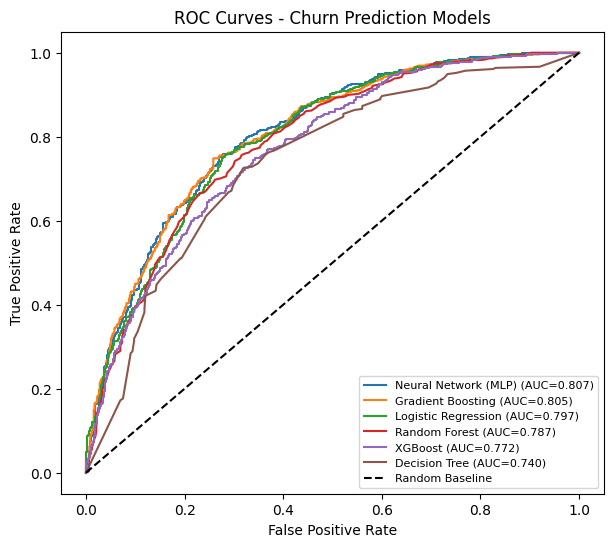

In [11]:
import matplotlib.pyplot as plt

plot_list = ["Neural Network (MLP)", "Gradient Boosting", "Logistic Regression",
              "Random Forest", "XGBoost", "Decision Tree"]

plt.figure(figsize=(7, 6))
for name in plot_list:
    proba = models[name].predict_proba(X_test_s)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random Baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Churn Prediction Models")
plt.legend(fontsize=8)
plt.savefig("roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

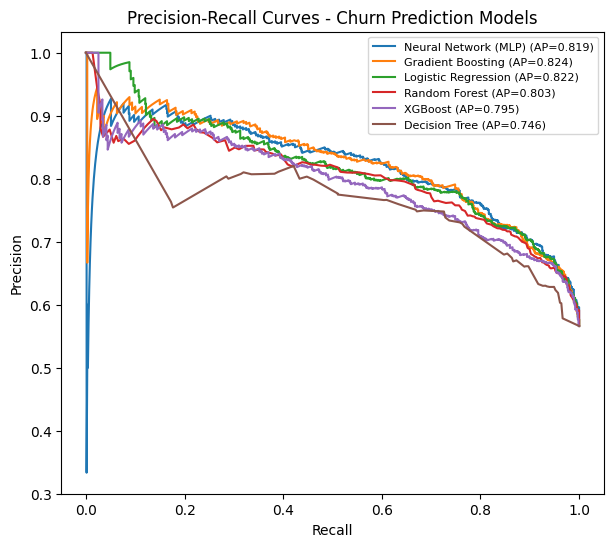

In [12]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(7, 6))
for name in plot_list:
    proba = models[name].predict_proba(X_test_s)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    plt.plot(rec, prec, label=f"{name} (AP={ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves - Churn Prediction Models")
plt.legend(fontsize=8)
plt.savefig("precision_recall_curves.png", dpi=150, bbox_inches="tight")
plt.show()

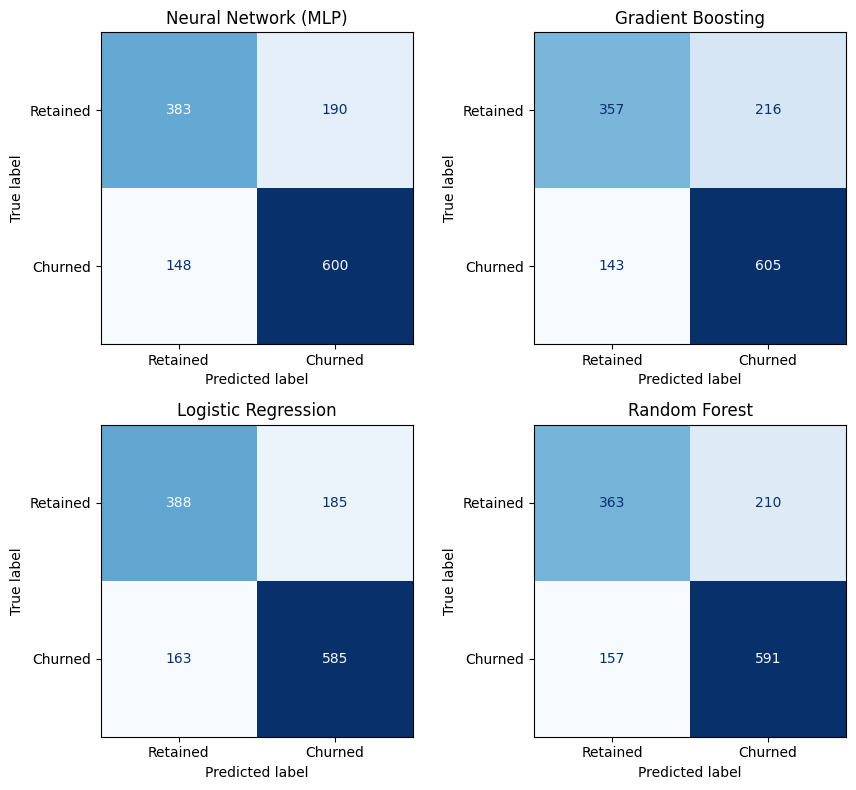

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

top4 = ["Neural Network (MLP)", "Gradient Boosting", "Logistic Regression", "Random Forest"]
fig, axes = plt.subplots(2, 2, figsize=(9, 8))
for ax, name in zip(axes.ravel(), top4):
    pred = models[name].predict(X_test_s)
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=["Retained", "Churned"]).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

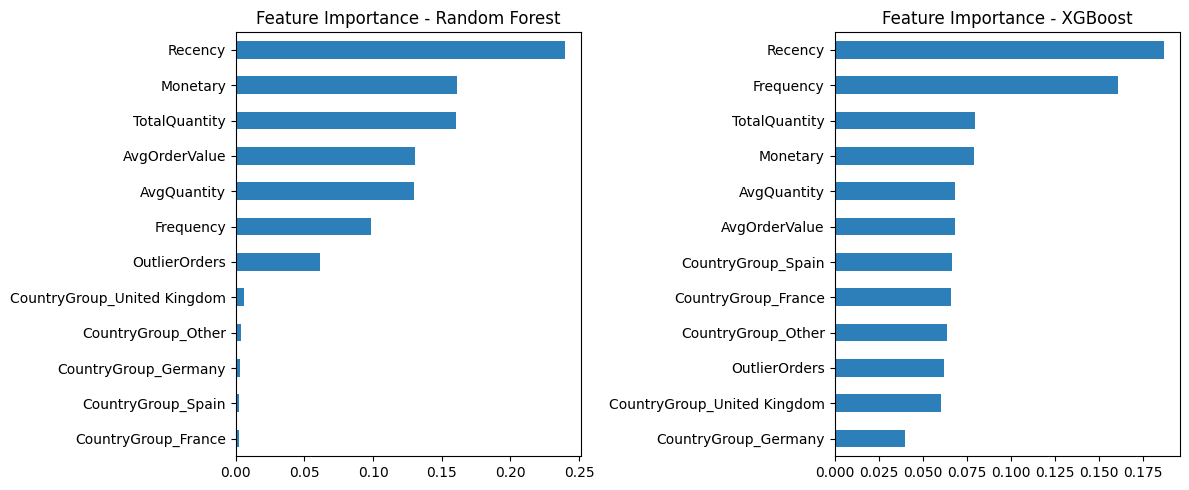

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, name in zip(axes, ["Random Forest", "XGBoost"]):
    importances = pd.Series(models[name].feature_importances_, index=X.columns).sort_values()
    importances.plot(kind="barh", ax=ax, color="#2C7FB8")
    ax.set_title(f"Feature Importance - {name}")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
from sklearn.model_selection import GridSearchCV

# Baseline (before tuning)
gb_base = GradientBoostingClassifier(random_state=42)
gb_base.fit(X_train_s, y_train)
pred = gb_base.predict(X_test_s)
proba = gb_base.predict_proba(X_test_s)[:, 1]
print("BEFORE tuning - Gradient Boosting")
print(f"  Accuracy={accuracy_score(y_test,pred):.3f}  F1={f1_score(y_test,pred):.3f}  AUC={roc_auc_score(y_test,proba):.3f}")

# Grid search
gb_grid = {"n_estimators": [100, 200], "learning_rate": [0.05, 0.1], "max_depth": [2, 3]}
gb_search = GridSearchCV(GradientBoostingClassifier(random_state=42), gb_grid, cv=3, scoring="roc_auc", n_jobs=-1)
gb_search.fit(X_train_s, y_train)

pred = gb_search.best_estimator_.predict(X_test_s)
proba = gb_search.best_estimator_.predict_proba(X_test_s)[:, 1]
print(f"\nBest params: {gb_search.best_params_}")
print("AFTER tuning - Gradient Boosting")
print(f"  Accuracy={accuracy_score(y_test,pred):.3f}  F1={f1_score(y_test,pred):.3f}  AUC={roc_auc_score(y_test,proba):.3f}")

BEFORE tuning - Gradient Boosting
  Accuracy=0.728  F1=0.771  AUC=0.805

Best params: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100}
AFTER tuning - Gradient Boosting
  Accuracy=0.735  F1=0.776  AUC=0.807


In [16]:
lr_base = LogisticRegression(max_iter=1000, random_state=42)
lr_base.fit(X_train_s, y_train)
pred = lr_base.predict(X_test_s)
proba = lr_base.predict_proba(X_test_s)[:, 1]
print("BEFORE tuning - Logistic Regression")
print(f"  Accuracy={accuracy_score(y_test,pred):.3f}  F1={f1_score(y_test,pred):.3f}  AUC={roc_auc_score(y_test,proba):.3f}")

lr_grid = {"C": [0.01, 0.1, 1, 10, 100], "solver": ["lbfgs", "liblinear"]}
lr_search = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), lr_grid, cv=3, scoring="roc_auc", n_jobs=-1)
lr_search.fit(X_train_s, y_train)

pred = lr_search.best_estimator_.predict(X_test_s)
proba = lr_search.best_estimator_.predict_proba(X_test_s)[:, 1]
print(f"\nBest params: {lr_search.best_params_}")
print("AFTER tuning - Logistic Regression")
print(f"  Accuracy={accuracy_score(y_test,pred):.3f}  F1={f1_score(y_test,pred):.3f}  AUC={roc_auc_score(y_test,proba):.3f}")

BEFORE tuning - Logistic Regression
  Accuracy=0.737  F1=0.771  AUC=0.797

Best params: {'C': 0.1, 'solver': 'liblinear'}
AFTER tuning - Logistic Regression
  Accuracy=0.734  F1=0.768  AUC=0.797


In [17]:
hv_features = ["Recency", "Frequency", "AvgQuantity", "TotalQuantity", "OutlierOrders", "CountryGroup"]
df_hv = pd.get_dummies(df[hv_features + ["HighValue"]], columns=["CountryGroup"], drop_first=True)
X_hv = df_hv.drop(columns=["HighValue"])
y_hv = df_hv["HighValue"].astype(int)

Xtr, Xte, ytr, yte = train_test_split(X_hv, y_hv, test_size=0.25, random_state=42, stratify=y_hv)
sc = StandardScaler()
Xtr_s, Xte_s = sc.fit_transform(Xtr), sc.transform(Xte)

hv_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=7),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=6),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42),
}

hv_results = []
for name, model in hv_models.items():
    model.fit(Xtr_s, ytr)
    pred = model.predict(Xte_s)
    proba = model.predict_proba(Xte_s)[:, 1]
    hv_results.append({
        "Model": name,
        "Accuracy": accuracy_score(yte, pred),
        "Precision": precision_score(yte, pred),
        "Recall": recall_score(yte, pred),
        "F1_Score": f1_score(yte, pred),
        "ROC_AUC": roc_auc_score(yte, proba)
    })

pd.DataFrame(hv_results).sort_values("ROC_AUC", ascending=False).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,XGBoost,0.959879,0.910506,0.886364,0.898273,0.989790
1,Random Forest,0.962907,0.921569,0.890152,0.905588,0.989500
2,Gradient Boosting,0.960636,0.904580,0.897727,0.901141,0.988036
3,Logistic Regression,0.950038,0.926724,0.814394,0.866935,0.987619
4,K-Nearest Neighbors,0.949281,0.919149,0.818182,0.865731,0.983390
5,Decision Tree,0.950795,0.861818,0.897727,0.879406,0.954606


In [18]:
seg_features = ["Recency", "Frequency", "Monetary", "AvgOrderValue", "AvgQuantity", "TotalQuantity"]
X_seg = df[seg_features]
y_seg = df["Segment"].astype(int) - 1

print("Segment class sizes:", dict(y_seg.value_counts().sort_index()))

Xtr2, Xte2, ytr2, yte2 = train_test_split(X_seg, y_seg, test_size=0.25, random_state=42, stratify=y_seg)
sc2 = StandardScaler()
Xtr2_s, Xte2_s = sc2.fit_transform(Xtr2), sc2.transform(Xte2)

seg_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=6),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(eval_metric="mlogloss", random_state=42),
}

seg_results = []
for name, model in seg_models.items():
    model.fit(Xtr2_s, ytr2)
    pred = model.predict(Xte2_s)
    seg_results.append({
        "Model": name,
        "Accuracy": accuracy_score(yte2, pred),
        "Precision_macro": precision_score(yte2, pred, average="macro", zero_division=0),
        "Recall_macro": recall_score(yte2, pred, average="macro", zero_division=0),
        "F1_macro": f1_score(yte2, pred, average="macro", zero_division=0)
    })

pd.DataFrame(seg_results).sort_values("F1_macro", ascending=False).reset_index(drop=True)

Segment class sizes: {0: np.int64(2144), 1: np.int64(246), 2: np.int64(2876), 3: np.int64(15)}


,Model,Accuracy,Precision_macro,Recall_macro,F1_macro
0,XGBoost,0.996972,0.994870,0.936219,0.961064
1,Random Forest,0.997729,0.995038,0.933120,0.959614
2,K-Nearest Neighbors,0.988645,0.979954,0.924669,0.947787
3,Logistic Regression,0.992430,0.981796,0.919276,0.946068
4,Decision Tree,0.995458,0.928126,0.921023,0.924510
